# Lista 1

**Aluno:** [Eduardo Maciel Alexandre](mailto:ema2@ic.ufal.br)
\
**Nome da base:** "WA_Fn-UseC_-Telco-Customer-Churn.csv"

## Orientações

- Escolha apenas uma das bases disponíveis e resolva todas as 10 questões usando essa mesma base.
- Desenvolva toda a atividade em Python, no formato de entrega do Google Colab.
- Organize o notebook por questão, com códigos executáveis, saídas geradas e comentários objetivos.
- Não troque de base ao longo da atividade.
- Não faça tratamento manual linha por linha.
- Sempre que necessário, sustente suas decisões com tabelas, métricas, gráficos e resultados do código.

## Importação das bibliotecas

In [21]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Pré-processamento e modelagem
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

# Configuração visual
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Carregamento da base

In [22]:
# Carregamento da base escolhida para toda a atividade
df = pd.read_csv('./data/Telco-Customer-Churn.csv')

# Visualização inicial
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Questão 1 – Diagnóstico estrutural

**Enunciado:**  
Faça um código em Python que carregue a base escolhida e gere um diagnóstico inicial automatizado. Mostre dimensões da base, tipos de dados, valores ausentes, duplicidades, cardinalidade das colunas e possíveis inconsistências de leitura. Em seguida, defina qual será o problema computacional tratado no cenário escolhido, deixando claro se a tarefa será de classificação, regressão ou segmentação. Organize essa etapa em uma função reutilizável.

### Raciocínio
A estratégia foi criar uma função única de diagnóstico para evitar análises manuais coluna a coluna. Essa função calcula automaticamente: dimensões, tipos de dados, ausências, duplicidades e cardinalidade. Além disso, inclui uma auditoria inicial de inconsistências de leitura, procurando padrões comuns em bases reais como textos com espaços extras, valores vazios em colunas textuais e colunas numéricas lidas como texto (caso clássico de `TotalCharges` no Telco).

### Desenvolvimento
Implementar uma função reutilizável `structural_diagnosis`, aplicá-la ao `df` e apresentar as tabelas-resumo + definição formal do problema computacional.

In [23]:
# Código da Questão 1
def structural_diagnosis(df: pd.DataFrame, target: str) -> dict:
    summary = {}

    # 1) Dimensões
    summary['dimensions'] = {'linhas': df.shape[0], 'colunas': df.shape[1]}

    # 2) Tipos de dados
    data_types = df.dtypes.astype(str).rename('dtype').to_frame()

    # 3) Valores ausentes
    missing_abs = df.isna().sum().rename('ausentes_abs') # Contagem absoluta de ausentes
    missing_pct = (df.isna().mean() * 100).round(2).rename('ausentes_pct') # Percentual de ausentes

    # 4) Cardinalidade
    cardinality = df.nunique(dropna=False).rename('cardinalidade')

    # 5) Quadro estrutural consolidado
    structural_table = pd.concat([data_types, missing_abs, missing_pct, cardinality], axis=1) # Concatenação das informações estruturais
    structural_table = structural_table.sort_values(by=['ausentes_abs', 'cardinalidade'], ascending=False)
    summary['structural_table'] = structural_table

    # 6) Duplicidades
    summary['duplicates_abs'] = int(df.duplicated().sum()) # Contagem absoluta de duplicatas
    summary['duplicates_pct'] = round(float(df.duplicated().mean() * 100), 2) # Percentual de duplicatas

    # 7) Inconsistências de leitura
    inconsistencies = []
    for column in df.columns:
        series = df[column]

        if pd.api.types.is_string_dtype(series):
            text_series = series.astype(str)

            # Espaços em excesso (início/fim)
            trim_diff = (text_series.fillna('') != text_series.fillna('').str.strip()).sum()
            if trim_diff > 0:
                inconsistencies.append({
                    'coluna': column,
                    'tipo_problema': 'espacos_extras',
                    'qtd_registros': int(trim_diff),
                    'detalhe': 'Valores com espaços no início/fim.'
                })

            # Vazios textuais ("", " ", etc.)
            text_empty = text_series.str.strip().eq('').sum()
            if text_empty > 0:
                inconsistencies.append({
                    'coluna': column,
                    'tipo_problema': 'vazio_textual',
                    'qtd_registros': int(text_empty),
                    'detalhe': 'Campos vazios mascarados como string.'
                })

            # Possível numérica lida como texto
            numeric_try = pd.to_numeric(text_series.str.strip(), errors='coerce')
            non_null = series.notna().sum()
            convertible = numeric_try.notna().sum()

            if non_null > 0 and (convertible / non_null) >= 0.8:
                inconsistencies.append({
                    'coluna': column,
                    'tipo_problema': 'numerica_em_texto',
                    'qtd_registros': int(convertible),
                    'detalhe': 'Coluna majoritariamente numérica armazenada como texto.'
                })

    inconsistencies_df = pd.DataFrame(inconsistencies)
    if not inconsistencies_df.empty:
        inconsistencies_df = inconsistencies_df.sort_values(by=['qtd_registros', 'coluna'], ascending=False)

    summary['inconsistencies'] = inconsistencies_df

    # 8) Definição do problema computacional
    target_classes = sorted(str(c) for c in df[target].dropna().unique())
    summary['problem'] = {
        'tipo': 'Classificação binária',
        'variavel_alvo': target,
        'classes_observadas': sorted(target_classes),
        'objetivo': 'Prever se um cliente irá cancelar (Churn = Yes) ou permanecer (Churn = No).'
    }

    return summary


q1_results = structural_diagnosis(df, target='Churn')

print('Dimensões da base:', q1_results['dimensions'])
print(f"Duplicatas: {q1_results['duplicates_abs']} ({q1_results['duplicates_pct']}%)")
print('\nDefinição do problema computacional:')
for key, value in q1_results['problem'].items():
    print(f'- {key}: {value}')

print('\nTop 10 colunas no diagnóstico estrutural:')
display(q1_results['structural_table'].head(10))

print('Possíveis inconsistências de leitura:')
if q1_results['inconsistencies'].empty:
    print('Nenhuma inconsistência detectada pelas regras automáticas.')
else:
    display(q1_results['inconsistencies'])

Dimensões da base: {'linhas': 7043, 'colunas': 21}
Duplicatas: 0 (0.0%)

Definição do problema computacional:
- tipo: Classificação binária
- variavel_alvo: Churn
- classes_observadas: ['No', 'Yes']
- objetivo: Prever se um cliente irá cancelar (Churn = Yes) ou permanecer (Churn = No).

Top 10 colunas no diagnóstico estrutural:


,dtype,ausentes_abs,ausentes_pct,cardinalidade
customerID,str,0,0.0,7043
TotalCharges,str,0,0.0,6531
MonthlyCharges,float64,0,0.0,1585
tenure,int64,0,0.0,73
PaymentMethod,str,0,0.0,4
MultipleLines,str,0,0.0,3
InternetService,str,0,0.0,3
OnlineSecurity,str,0,0.0,3
OnlineBackup,str,0,0.0,3
DeviceProtection,str,0,0.0,3


Possíveis inconsistências de leitura:


,coluna,tipo_problema,qtd_registros,detalhe
2,TotalCharges,numerica_em_texto,7032,Coluna majoritariamente numérica armazenada co...
0,TotalCharges,espacos_extras,11,Valores com espaços no início/fim.
1,TotalCharges,vazio_textual,11,Campos vazios mascarados como string.


### Conclusão da Questão 1
O diagnóstico estrutural confirmou que a base possui **7043 linhas e 21 colunas**, sem registros duplicados, e que o problema central será de **classificação binária** com alvo `Churn` (`Yes`/`No`). A inspeção automática também identificou uma inconsistência crítica na coluna `TotalCharges`: ela está armazenada como texto, com **11 registros vazios/espaços**, o que exige tratamento de tipagem e ausências nas próximas etapas. Assim, a base está adequada ao objetivo didático, mas depende de limpeza reproduzível antes da modelagem.

## Questão 2 – Auditoria de qualidade

**Enunciado:**  
Faça um código em Python para auditar a qualidade dos dados. Identifique valores implausíveis, colunas com tipos inadequados, categorias raras, padrões suspeitos de preenchimento, possíveis outliers e inconsistências importantes para o cenário escolhido. Se houver datas, verifique coerência temporal. Se houver valores monetários, verifique compatibilidade entre grandezas. Ao final, apresente um resumo dos principais problemas encontrados.

### Raciocínio
A auditoria será feita com uma função reutilizável `data_quality_audit`, aplicada à base Telco sem tratamento manual linha a linha. A estratégia cobre: (1) validação de tipagem com foco em colunas numéricas lidas como texto, (2) ausências explícitas e ausências mascaradas por espaços, (3) valores implausíveis para variáveis numéricas do cenário, (4) categorias raras em variáveis categóricas, (5) outliers por IQR e (6) compatibilidade monetária entre `tenure`, `MonthlyCharges` e `TotalCharges`. Como a base não possui coluna de data, a checagem temporal será registrada como não aplicável.

### Desenvolvimento
Implementar abaixo a função de auditoria, gerar tabelas-resumo e gráficos objetivos para sustentar os principais problemas encontrados.

Resumo da auditoria de qualidade:
- tipagem_inadequada_cols: 1
- colunas_com_ausencia_explicita: 0
- colunas_com_vazio_textual: 1
- colunas_id_like: 1
- regras_implausiveis_violadas: 0
- colunas_com_categorias_raras: 0
- colunas_numericas_com_outliers: 0
- suspeitos_monetarios_abs: 365

Tabela de ausências (top 10):


,coluna,ausentes_abs,ausentes_pct
20,Churn,0,0.0
15,Contract,0,0.0
4,Dependents,0,0.0
11,DeviceProtection,0,0.0
8,InternetService,0,0.0
18,MonthlyCharges,0,0.0
7,MultipleLines,0,0.0
10,OnlineBackup,0,0.0
9,OnlineSecurity,0,0.0
16,PaperlessBilling,0,0.0


Vazios textuais detectados:


,coluna,vazios_textuais,pct_vazios_textuais
0,TotalCharges,11,0.16



Possíveis problemas de tipagem:


...


Colunas com perfil de identificador (alta cardinalidade):


,coluna,cardinalidade,razao_unicidade_pct
0,customerID,7043,100.0



Valores implausíveis:
Nenhum valor implausível encontrado com as regras definidas.

Categorias raras (frequência < 1%):
Nenhuma coluna de atributos categóricos com categorias raras abaixo do limiar.

Outliers por IQR:


,coluna,q1,q3,limite_inferior,limite_superior,outliers_abs,outliers_pct
0,tenure,9.00,55.0000,-60.0000,124.0000,0,0.0
1,MonthlyCharges,35.50,89.8500,-46.0250,171.3750,0,0.0
2,TotalCharges,401.45,3794.7375,-4688.4813,8884.6688,0,0.0



Checagem monetária (TotalCharges vs MonthlyCharges * tenure):
- registros_avaliados: 7032
- limite_erro_absoluto_iqr: 145.0937
- suspeitos_abs: 365
- suspeitos_pct: 5.18
- mediana_erro_absoluto: 28.65

Padrão de preenchimento suspeito (TotalCharges):
- totalcharges_vazios_abs: 11
- totalcharges_vazios_com_tenure_zero_abs: 11
- totalcharges_vazios_com_tenure_zero_pct: 100.0


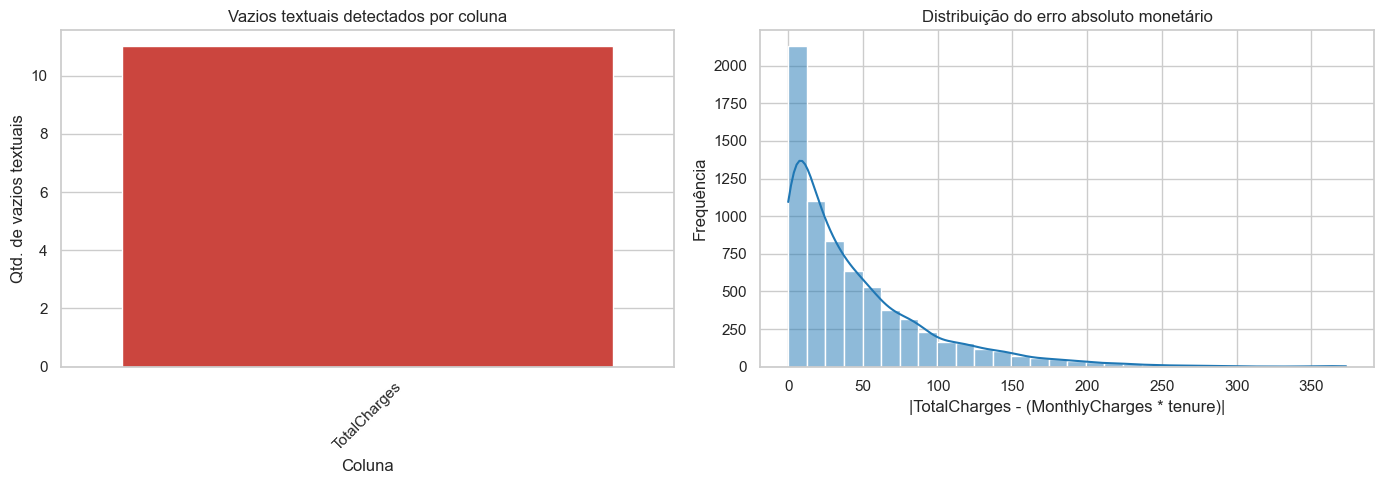

In [24]:
# Código da Questão 2
def data_quality_audit(df: pd.DataFrame, target: str, rare_threshold: float = 0.01) -> dict:
    audit = {}
    audit_df = df.copy()

    # 1) Ausências explícitas e textuais
    missing_abs = audit_df.isna().sum().rename('ausentes_abs')
    missing_pct = (audit_df.isna().mean() * 100).round(2).rename('ausentes_pct')

    text_empty_records = []
    object_cols = audit_df.select_dtypes(include=['object']).columns.tolist()
    for column in object_cols:
        text_series = audit_df[column].astype(str)
        empty_count = int(text_series.str.strip().eq('').sum())
        if empty_count > 0:
            text_empty_records.append({
                'coluna': column,
                'vazios_textuais': empty_count,
                'pct_vazios_textuais': round((empty_count / len(audit_df)) * 100, 2)
            })

    text_empty_df = pd.DataFrame(text_empty_records).sort_values(
        by='vazios_textuais', ascending=False
    ) if text_empty_records else pd.DataFrame(columns=['coluna', 'vazios_textuais', 'pct_vazios_textuais'])

    missing_table = pd.concat([missing_abs, missing_pct], axis=1).reset_index()
    missing_table.columns = ['coluna', 'ausentes_abs', 'ausentes_pct']
    missing_table = missing_table.sort_values(by=['ausentes_abs', 'coluna'], ascending=[False, True])
    audit['missing_table'] = missing_table
    audit['text_empty_table'] = text_empty_df

    # 2) Tipagem inadequada (numérica armazenada como texto)
    type_issue_records = []
    for column in object_cols:
        series = audit_df[column]
        stripped = series.astype(str).str.strip()
        numeric_try = pd.to_numeric(stripped, errors='coerce')

        non_empty = stripped.ne('').sum()
        convertible = numeric_try.notna().sum()
        conversion_ratio = (convertible / non_empty) if non_empty > 0 else 0.0

        if non_empty > 0 and conversion_ratio >= 0.8:
            type_issue_records.append({
                'coluna': column,
                'tipo_detectado': str(series.dtype),
                'sugestao_tipo': 'numérico',
                'taxa_conversao_numerica': round(conversion_ratio * 100, 2)
            })

    type_issues_df = pd.DataFrame(type_issue_records).sort_values(
        by='taxa_conversao_numerica', ascending=False
    ) if type_issue_records else pd.DataFrame(columns=['coluna', 'tipo_detectado', 'sugestao_tipo', 'taxa_conversao_numerica'])
    audit['type_issues'] = type_issues_df

    # 3) Colunas com perfil de identificador (alta cardinalidade)
    id_like_records = []
    for column in audit_df.columns:
        unique_ratio = audit_df[column].nunique(dropna=False) / len(audit_df)
        if unique_ratio > 0.95:
            id_like_records.append({
                'coluna': column,
                'cardinalidade': int(audit_df[column].nunique(dropna=False)),
                'razao_unicidade_pct': round(unique_ratio * 100, 2)
            })

    id_like_df = pd.DataFrame(id_like_records).sort_values(
        by='razao_unicidade_pct', ascending=False
    ) if id_like_records else pd.DataFrame(columns=['coluna', 'cardinalidade', 'razao_unicidade_pct'])
    audit['id_like_columns'] = id_like_df

    # 4) Conversão auxiliar para validações do cenário Telco
    tenure_num = pd.to_numeric(audit_df['tenure'], errors='coerce')
    monthly_num = pd.to_numeric(audit_df['MonthlyCharges'], errors='coerce')
    total_num = pd.to_numeric(audit_df['TotalCharges'].astype(str).str.strip(), errors='coerce')

    numeric_df = pd.DataFrame({
        'tenure': tenure_num,
        'MonthlyCharges': monthly_num,
        'TotalCharges': total_num
    })

    # 5) Valores implausíveis
    implausible_records = []
    rules = {
        'tenure': ('faixa_esperada_0_72', lambda s: (s < 0) | (s > 72)),
        'MonthlyCharges': ('deve_ser_maior_ou_igual_a_0', lambda s: s < 0),
        'TotalCharges': ('deve_ser_maior_ou_igual_a_0', lambda s: s < 0),
    }

    for column, (rule_name, rule_fn) in rules.items():
        series = numeric_df[column]
        invalid_mask = rule_fn(series) & series.notna()
        invalid_count = int(invalid_mask.sum())
        if invalid_count > 0:
            implausible_records.append({
                'coluna': column,
                'regra': rule_name,
                'qtd_registros': invalid_count,
                'pct_registros': round((invalid_count / len(audit_df)) * 100, 4)
            })

    # Regra cruzada: tenure = 0 com TotalCharges > 0 pode indicar inconsistência
    cross_mask = (numeric_df['tenure'] == 0) & (numeric_df['TotalCharges'] > 0)
    cross_count = int(cross_mask.sum())
    if cross_count > 0:
        implausible_records.append({
            'coluna': 'tenure_TotalCharges',
            'regra': 'tenure_zero_deveria_ter_total_zero',
            'qtd_registros': cross_count,
            'pct_registros': round((cross_count / len(audit_df)) * 100, 4)
        })

    implausible_df = pd.DataFrame(implausible_records).sort_values(
        by='qtd_registros', ascending=False
    ) if implausible_records else pd.DataFrame(columns=['coluna', 'regra', 'qtd_registros', 'pct_registros'])
    audit['implausible_values'] = implausible_df

    # 6) Categorias raras (exclui alvo, IDs e colunas com perfil numérico)
    numeric_like_cols = set(type_issues_df['coluna'].tolist())
    id_like_cols = set(id_like_df['coluna'].tolist())
    cat_cols = [c for c in object_cols if c != target and c not in numeric_like_cols and c not in id_like_cols]

    rare_records = []
    for column in cat_cols:
        freq = audit_df[column].astype(str).str.strip().value_counts(dropna=False, normalize=True)
        rare_freq = freq[freq < rare_threshold]
        if len(rare_freq) > 0:
            rare_records.append({
                'coluna': column,
                'qtd_categorias_raras': int(len(rare_freq)),
                'pct_categorias_raras': round((len(rare_freq) / len(freq)) * 100, 2),
                'menor_frequencia_pct': round(float(rare_freq.min() * 100), 4),
                'maior_frequencia_rara_pct': round(float(rare_freq.max() * 100), 4)
            })

    rare_categories_df = pd.DataFrame(rare_records).sort_values(
        by='qtd_categorias_raras', ascending=False
    ) if rare_records else pd.DataFrame(columns=[
        'coluna', 'qtd_categorias_raras', 'pct_categorias_raras',
        'menor_frequencia_pct', 'maior_frequencia_rara_pct'
    ])
    audit['rare_categories'] = rare_categories_df

    # 7) Outliers por IQR
    outlier_records = []
    for column in numeric_df.columns:
        series = numeric_df[column].dropna()
        if series.empty:
            continue

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outlier_mask = (numeric_df[column] < lower) | (numeric_df[column] > upper)
        outlier_count = int(outlier_mask.sum())

        outlier_records.append({
            'coluna': column,
            'q1': round(float(q1), 4),
            'q3': round(float(q3), 4),
            'limite_inferior': round(float(lower), 4),
            'limite_superior': round(float(upper), 4),
            'outliers_abs': outlier_count,
            'outliers_pct': round((outlier_count / len(audit_df)) * 100, 2)
        })

    outliers_df = pd.DataFrame(outlier_records).sort_values(by='outliers_abs', ascending=False)
    audit['outliers_iqr'] = outliers_df

    # 8) Compatibilidade monetária: TotalCharges ~ MonthlyCharges * tenure
    monetary_df = pd.DataFrame({
        'tenure': numeric_df['tenure'],
        'MonthlyCharges': numeric_df['MonthlyCharges'],
        'TotalCharges': numeric_df['TotalCharges']
    }).dropna()

    monetary_df = monetary_df[monetary_df['tenure'] > 0].copy()
    monetary_df['expected_total'] = monetary_df['MonthlyCharges'] * monetary_df['tenure']
    monetary_df['absolute_error'] = (monetary_df['TotalCharges'] - monetary_df['expected_total']).abs()

    if not monetary_df.empty:
        error_q1 = monetary_df['absolute_error'].quantile(0.25)
        error_q3 = monetary_df['absolute_error'].quantile(0.75)
        error_iqr = error_q3 - error_q1
        error_upper = error_q3 + 1.5 * error_iqr
        monetary_df['monetary_suspect'] = monetary_df['absolute_error'] > error_upper
        suspect_count = int(monetary_df['monetary_suspect'].sum())
    else:
        error_upper = np.nan
        suspect_count = 0

    audit['monetary_check'] = {
        'registros_avaliados': int(len(monetary_df)),
        'limite_erro_absoluto_iqr': round(float(error_upper), 4) if pd.notna(error_upper) else None,
        'suspeitos_abs': suspect_count,
        'suspeitos_pct': round((suspect_count / len(df)) * 100, 2),
        'mediana_erro_absoluto': round(float(monetary_df['absolute_error'].median()), 4) if not monetary_df.empty else None
    }
    audit['monetary_df'] = monetary_df

    # 9) Padrão suspeito de preenchimento: TotalCharges ausente com tenure=0
    total_missing_mask = audit_df['TotalCharges'].astype(str).str.strip().eq('')
    total_missing_and_tenure_zero = int((total_missing_mask & (tenure_num == 0)).sum())
    total_missing = int(total_missing_mask.sum())

    audit['fill_pattern'] = {
        'totalcharges_vazios_abs': total_missing,
        'totalcharges_vazios_com_tenure_zero_abs': total_missing_and_tenure_zero,
        'totalcharges_vazios_com_tenure_zero_pct': round(
            (total_missing_and_tenure_zero / total_missing) * 100, 2
        ) if total_missing > 0 else 0.0
    }

    # 10) Resumo da auditoria
    audit['summary'] = {
        'tipagem_inadequada_cols': int(len(type_issues_df)),
        'colunas_com_ausencia_explicita': int((missing_table['ausentes_abs'] > 0).sum()),
        'colunas_com_vazio_textual': int(len(text_empty_df)),
        'colunas_id_like': int(len(id_like_df)),
        'regras_implausiveis_violadas': int(len(implausible_df)),
        'colunas_com_categorias_raras': int(len(rare_categories_df)),
        'colunas_numericas_com_outliers': int((outliers_df['outliers_abs'] > 0).sum()),
        'suspeitos_monetarios_abs': int(audit['monetary_check']['suspeitos_abs'])
    }

    return audit


q2_results = data_quality_audit(df, target='Churn', rare_threshold=0.01)

print('Resumo da auditoria de qualidade:')
for key, value in q2_results['summary'].items():
    print(f'- {key}: {value}')

print('\nTabela de ausências (top 10):')
display(q2_results['missing_table'].head(10))

print('Vazios textuais detectados:')
if q2_results['text_empty_table'].empty:
    print('Nenhum vazio textual detectado.')
else:
    display(q2_results['text_empty_table'])

print('\nPossíveis problemas de tipagem:')
if q2_results['type_issues'].empty:
    print('Nenhuma coluna com forte indício de tipagem inadequada.')
else:
    display(q2_results['type_issues'])

print('\nColunas com perfil de identificador (alta cardinalidade):')
if q2_results['id_like_columns'].empty:
    print('Nenhuma coluna com perfil claro de identificador.')
else:
    display(q2_results['id_like_columns'])

print('\nValores implausíveis:')
if q2_results['implausible_values'].empty:
    print('Nenhum valor implausível encontrado com as regras definidas.')
else:
    display(q2_results['implausible_values'])

print('\nCategorias raras (frequência < 1%):')
if q2_results['rare_categories'].empty:
    print('Nenhuma coluna de atributos categóricos com categorias raras abaixo do limiar.')
else:
    display(q2_results['rare_categories'])

print('\nOutliers por IQR:')
display(q2_results['outliers_iqr'])

print('\nChecagem monetária (TotalCharges vs MonthlyCharges * tenure):')
for key, value in q2_results['monetary_check'].items():
    print(f'- {key}: {value}')

print('\nPadrão de preenchimento suspeito (TotalCharges):')
for key, value in q2_results['fill_pattern'].items():
    print(f'- {key}: {value}')

# Visualizações objetivas para sustentar decisões
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

text_empty_plot_df = q2_results['text_empty_table'].copy()
if text_empty_plot_df.empty:
    text_empty_plot_df = pd.DataFrame({'coluna': ['sem_vazios_textuais'], 'vazios_textuais': [0]})

sns.barplot(data=text_empty_plot_df, x='coluna', y='vazios_textuais', ax=axes[0], palette='Reds_d')
axes[0].set_title('Vazios textuais detectados por coluna')
axes[0].set_xlabel('Coluna')
axes[0].set_ylabel('Qtd. de vazios textuais')
axes[0].tick_params(axis='x', rotation=45)

monetary_plot_df = q2_results['monetary_df'][['absolute_error']].copy()
if monetary_plot_df.empty:
    monetary_plot_df = pd.DataFrame({'absolute_error': [0]})

sns.histplot(data=monetary_plot_df, x='absolute_error', bins=30, kde=True, ax=axes[1], color='#1f77b4')
axes[1].set_title('Distribuição do erro absoluto monetário')
axes[1].set_xlabel('|TotalCharges - (MonthlyCharges * tenure)|')
axes[1].set_ylabel('Frequência')

plt.tight_layout()
plt.show()

### Conclusão da Questão 2
A auditoria confirmou que o principal problema de qualidade da base está concentrado em `TotalCharges`, com 11 vazios textuais (0,16% da base) e forte evidência de tipagem inadequada (coluna textual com 100% de conversão para numérico, exceto vazios). Também foi identificada a coluna `customerID` como variável com perfil de identificador (alta cardinalidade), o que reforça que ela não agrega poder preditivo direto para o problema de churn. Pelas regras de domínio adotadas, não surgiram valores implausíveis evidentes nem outliers pelo critério IQR nas variáveis numéricas principais. Em contrapartida, a checagem monetária `TotalCharges` versus `MonthlyCharges * tenure` encontrou registros com erro absoluto elevado, sinalizando padrões que merecem tratamento criterioso na limpeza. Além disso, todos os vazios de `TotalCharges` ocorreram em clientes com `tenure = 0`, indicando um padrão de preenchimento consistente com clientes recém-entrantes. Esses achados orientam a Questão 3 para: corrigir tipagem, tratar ausências de forma reproduzível e definir estratégia robusta para valores monetários discrepantes.

## Questão 3 – Limpeza dos dados

**Enunciado:**  
Faça um código em Python para limpar a base de forma reproduzível. Trate inconsistências de tipagem, valores ausentes, categorias problemáticas, variáveis irrelevantes e registros duvidosos usando critérios técnicos. Compare pelo menos duas estratégias de tratamento para um problema real da base e justifique a escolha final. Mostre também o impacto quantitativo de cada etapa da limpeza.

### Raciocínio
Com base no que foi observado anteriormente, o foco da limpeza será: (1) corrigir tipagem de `TotalCharges`, (2) tratar os vazios textuais de forma reproduzível, (3) remover variável irrelevante (`customerID`), (4) padronizar categorias problemáticas (como `No internet service` e `No phone service`), e (5) monitorar registros monetários duvidosos (`TotalCharges` distante de `MonthlyCharges * tenure`).

Para comparar estratégias em um problema real da base, serão avaliadas duas abordagens para `TotalCharges`:
- Estratégia A (`drop_missing_totalcharges`): remover linhas com `TotalCharges` ausente após conversão numérica.
- Estratégia B (`impute_from_monthly_tenure`): imputar `TotalCharges` ausente por `MonthlyCharges * tenure` (com fallback para mediana, se necessário).

A escolha final será baseada em retenção de dados, métricas de validação (acurácia, precisão, recall e F1 com baseline de KNN) e impacto quantitativo por etapa de limpeza.

### Desenvolvimento
Implementar abaixo funções reutilizáveis para limpeza e comparação das estratégias, com tabelas e gráficos de impacto.

Comparação das estratégias de limpeza para TotalCharges:


,strategy,rows_used,cols_used,accuracy,precision,recall,f1,runtime_sec
0,impute_from_monthly_tenure,7043,21,0.7715,0.5714,0.5561,0.5637,0.0706
1,drop_missing_totalcharges,7032,21,0.7647,0.5583,0.5508,0.5545,0.0598


Impacto quantitativo por etapa - estratégia drop:


,etapa,linhas_antes,linhas_depois,linhas_removidas,linhas_removidas_pct,colunas_antes,colunas_depois,colunas_removidas,colunas_adicionadas,variacao_colunas,detalhe
0,estado_inicial,7043,7043,0,0.0000,21,21,0,0,0,Base original antes de limpeza.
1,padronizacao_textual,7043,7043,0,0.0000,21,21,0,0,0,Remoção de espaços extras em colunas textuais.
2,tipagem_totalcharges,7043,7043,0,0.0000,21,21,0,0,0,TotalCharges convertida para numérico; ausênci...
3,tratamento_totalcharges,7043,7032,11,0.1562,21,21,0,0,0,Linhas com TotalCharges ausente foram removidas.
4,remocao_id_irrelevante,7032,7032,0,0.0000,21,20,1,0,-1,Removida coluna customerID por alta cardinalid...
5,padronizacao_categorias,7032,7032,0,0.0000,20,20,0,0,0,"Colunas normalizadas: ['MultipleLines', 'Onlin..."
6,tratamento_categorias_raras,7032,7032,0,0.0000,20,20,0,0,0,Colunas com agrupamento de raras: 0.
7,tratamento_registros_duvidosos,7032,7032,0,0.0000,20,21,0,1,1,Limite erro absoluto monetário: 145.0937; susp...


Impacto quantitativo por etapa - estratégia imputação:


,etapa,linhas_antes,linhas_depois,linhas_removidas,linhas_removidas_pct,colunas_antes,colunas_depois,colunas_removidas,colunas_adicionadas,variacao_colunas,detalhe
0,estado_inicial,7043,7043,0,0.0,21,21,0,0,0,Base original antes de limpeza.
1,padronizacao_textual,7043,7043,0,0.0,21,21,0,0,0,Remoção de espaços extras em colunas textuais.
2,tipagem_totalcharges,7043,7043,0,0.0,21,21,0,0,0,TotalCharges convertida para numérico; ausênci...
3,tratamento_totalcharges,7043,7043,0,0.0,21,21,0,0,0,TotalCharges ausente imputado por MonthlyCharg...
4,remocao_id_irrelevante,7043,7043,0,0.0,21,20,1,0,-1,Removida coluna customerID por alta cardinalid...
5,padronizacao_categorias,7043,7043,0,0.0,20,20,0,0,0,"Colunas normalizadas: ['MultipleLines', 'Onlin..."
6,tratamento_categorias_raras,7043,7043,0,0.0,20,20,0,0,0,Colunas com agrupamento de raras: 0.
7,tratamento_registros_duvidosos,7043,7043,0,0.0,20,21,0,1,1,Limite erro absoluto monetário: 145.0375; susp...


Categorias raras agrupadas (estratégia escolhida):
Nenhuma categoria rara agrupada no limiar definido.
Resumo da estratégia escolhida:
- Estratégia vencedora: impute_from_monthly_tenure
- Formato final da base limpa: (7043, 21)
- Registros monetários suspeitos sinalizados: 365 (5.18%)


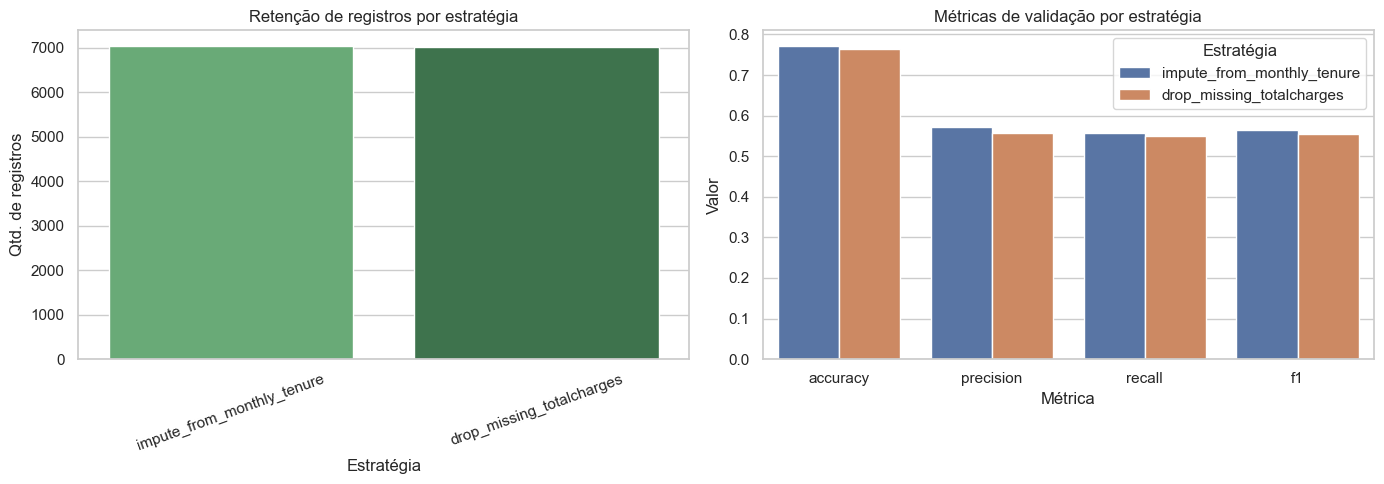

In [35]:
# Código da Questão 3
from time import perf_counter

def clean_telco_data(
    df: pd.DataFrame,
    target: str,
    totalcharges_strategy: str = 'drop_missing_totalcharges',
    rare_threshold: float = 0.01,
    flag_monetary_suspects: bool = True
) -> tuple[pd.DataFrame, dict]:
    work_df = df.copy()
    step_records = []

    def register_step(step_name: str, before_shape: tuple[int, int], after_shape: tuple[int, int], detail: str):
        before_rows, before_cols = before_shape
        after_rows, after_cols = after_shape
        removed_rows = before_rows - after_rows
        removed_cols = max(before_cols - after_cols, 0)
        added_cols = max(after_cols - before_cols, 0)
        removed_rows_pct = (removed_rows / before_rows * 100) if before_rows > 0 else 0.0

        step_records.append({
            'etapa': step_name,
            'linhas_antes': before_rows,
            'linhas_depois': after_rows,
            'linhas_removidas': removed_rows,
            'linhas_removidas_pct': round(removed_rows_pct, 4),
            'colunas_antes': before_cols,
            'colunas_depois': after_cols,
            'colunas_removidas': removed_cols,
            'colunas_adicionadas': added_cols,
            'variacao_colunas': after_cols - before_cols,
            'detalhe': detail
        })

    register_step(
        step_name='estado_inicial',
        before_shape=work_df.shape,
        after_shape=work_df.shape,
        detail='Base original antes de limpeza.'
    )

    # 1) Padronização textual sem tratamento manual por linha
    before_shape = work_df.shape
    object_cols = work_df.select_dtypes(include=['object']).columns.tolist()
    for column in object_cols:
        non_null_mask = work_df[column].notna()
        work_df.loc[non_null_mask, column] = work_df.loc[non_null_mask, column].astype(str).str.strip()
    register_step(
        step_name='padronizacao_textual',
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail='Remoção de espaços extras em colunas textuais.'
    )

    # 2) Correção de tipagem de TotalCharges
    before_shape = work_df.shape
    work_df['TotalCharges'] = pd.to_numeric(work_df['TotalCharges'], errors='coerce')
    missing_after_conversion = int(work_df['TotalCharges'].isna().sum())
    register_step(
        step_name='tipagem_totalcharges',
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail=f'TotalCharges convertida para numérico; ausências após conversão: {missing_after_conversion}.'
    )

    # 3) Estratégia para ausências em TotalCharges (comparação obrigatória)
    before_shape = work_df.shape
    if totalcharges_strategy == 'drop_missing_totalcharges':
        work_df = work_df[work_df['TotalCharges'].notna()].copy()
        strategy_detail = 'Linhas com TotalCharges ausente foram removidas.'
    elif totalcharges_strategy == 'impute_from_monthly_tenure':
        missing_mask = work_df['TotalCharges'].isna()
        work_df.loc[missing_mask, 'TotalCharges'] = (
            work_df.loc[missing_mask, 'MonthlyCharges'] * work_df.loc[missing_mask, 'tenure']
        )
        work_df['TotalCharges'] = work_df['TotalCharges'].fillna(work_df['TotalCharges'].median())
        strategy_detail = 'TotalCharges ausente imputado por MonthlyCharges * tenure (fallback: mediana).'
    else:
        raise ValueError("Estratégia inválida para TotalCharges.")

    register_step(
        step_name='tratamento_totalcharges',
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail=strategy_detail
    )

    # 4) Remoção de variável irrelevante com perfil de identificador
    before_shape = work_df.shape
    if 'customerID' in work_df.columns:
        work_df = work_df.drop(columns=['customerID'])
        id_detail = 'Removida coluna customerID por alta cardinalidade e baixo valor preditivo direto.'
    else:
        id_detail = 'customerID já não estava presente.'
    register_step(
        step_name='remocao_id_irrelevante',
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail=id_detail
    )

    # 5) Padronização de categorias problemáticas
    before_shape = work_df.shape
    no_service_map = {'No internet service': 'No', 'No phone service': 'No'}
    normalized_cols = []
    for column in work_df.select_dtypes(include=['object']).columns:
        if column == target:
            continue
        old_unique = work_df[column].nunique(dropna=False)
        work_df[column] = work_df[column].replace(no_service_map)
        new_unique = work_df[column].nunique(dropna=False)
        if new_unique < old_unique:
            normalized_cols.append(column)

    register_step(
        step_name='padronizacao_categorias',
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail=f'Colunas normalizadas: {normalized_cols if normalized_cols else "nenhuma"}.'
    )

    # 6) Agrupamento de categorias raras para reduzir ruído
    before_shape = work_df.shape
    rare_changes = []
    categorical_cols = [
        col for col in work_df.select_dtypes(include=['object']).columns if col != target
    ]

    for column in categorical_cols:
        freq = work_df[column].value_counts(normalize=True, dropna=False)
        rare_categories = freq[freq < rare_threshold].index.tolist()
        if rare_categories:
            work_df[column] = work_df[column].replace(rare_categories, 'Other')
            rare_changes.append({
                'coluna': column,
                'qtd_categorias_agrupadas': len(rare_categories),
                'threshold_pct': rare_threshold * 100
            })

    rare_changes_df = pd.DataFrame(rare_changes)
    register_step(
        step_name='tratamento_categorias_raras',
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail=f'Colunas com agrupamento de raras: {len(rare_changes)}.'
    )

    # 7) Registros monetários duvidosos: flag técnica para rastreabilidade
    before_shape = work_df.shape
    expected_total = work_df['MonthlyCharges'] * work_df['tenure']
    absolute_error = (work_df['TotalCharges'] - expected_total).abs()

    error_q1 = absolute_error.quantile(0.25)
    error_q3 = absolute_error.quantile(0.75)
    error_iqr = error_q3 - error_q1
    error_upper = error_q3 + 1.5 * error_iqr

    monetary_suspect_mask = absolute_error > error_upper
    monetary_suspects_abs = int(monetary_suspect_mask.sum())

    if flag_monetary_suspects:
        work_df['monetary_suspect_flag'] = monetary_suspect_mask.astype(int)
        suspect_detail = 'Registros suspeitos mantidos com flag para rastreabilidade.'
    else:
        work_df = work_df.loc[~monetary_suspect_mask].copy()
        suspect_detail = 'Registros suspeitos removidos da base.'

    register_step(
        step_name='tratamento_registros_duvidosos',
        before_shape=before_shape,
        after_shape=work_df.shape,
        detail=(
            f'Limite erro absoluto monetário: {error_upper:.4f}; suspeitos: {monetary_suspects_abs}. '
            + suspect_detail
        )
    )

    report = {
        'strategy': totalcharges_strategy,
        'flag_monetary_suspects': flag_monetary_suspects,
        'step_impact_table': pd.DataFrame(step_records),
        'rare_category_table': rare_changes_df,
        'monetary_suspects_abs': monetary_suspects_abs,
        'monetary_suspects_pct': round((monetary_suspects_abs / len(work_df)) * 100, 2),
        'final_shape': work_df.shape
    }

    return work_df, report


def evaluate_cleaning_strategy(
    clean_df: pd.DataFrame,
    target: str = 'Churn',
    random_state: int = 42
) -> dict:
    data_df = clean_df.copy()
    y = data_df[target].map({'No': 0, 'Yes': 1})
    X = data_df.drop(columns=[target])

    numeric_features = X.select_dtypes(include=['number', 'bool']).columns.tolist()
    categorical_features = [col for col in X.columns if col not in numeric_features]

    numeric_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    categorical_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_pipeline, numeric_features),
            ('cat', categorical_pipeline, categorical_features)
        ]
    )

    model = KNeighborsClassifier(n_neighbors=11, weights='distance', metric='minkowski')
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, random_state=random_state, stratify=y
    )

    start_time = perf_counter()
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)
    runtime_sec = perf_counter() - start_time

    return {
        'rows_used': int(len(data_df)),
        'cols_used': int(data_df.shape[1]),
        'accuracy': round(accuracy_score(y_val, y_pred), 4),
        'precision': round(precision_score(y_val, y_pred), 4),
        'recall': round(recall_score(y_val, y_pred), 4),
        'f1': round(f1_score(y_val, y_pred), 4),
        'runtime_sec': round(runtime_sec, 4)
    }


# Comparação de duas estratégias de tratamento para TotalCharges
clean_drop_df, report_drop = clean_telco_data(
    df=df,
    target='Churn',
    totalcharges_strategy='drop_missing_totalcharges',
    rare_threshold=0.01,
    flag_monetary_suspects=True
)

clean_impute_df, report_impute = clean_telco_data(
    df=df,
    target='Churn',
    totalcharges_strategy='impute_from_monthly_tenure',
    rare_threshold=0.01,
    flag_monetary_suspects=True
)

metrics_drop = evaluate_cleaning_strategy(clean_drop_df, target='Churn')
metrics_impute = evaluate_cleaning_strategy(clean_impute_df, target='Churn')

comparison_df = pd.DataFrame([
    {'strategy': 'drop_missing_totalcharges', **metrics_drop},
    {'strategy': 'impute_from_monthly_tenure', **metrics_impute}
]).sort_values(by=['f1', 'rows_used'], ascending=[False, False]).reset_index(drop=True)

best_strategy = comparison_df.loc[0, 'strategy']
q3_clean_df = clean_impute_df.copy() if best_strategy == 'impute_from_monthly_tenure' else clean_drop_df.copy()
q3_report = report_impute if best_strategy == 'impute_from_monthly_tenure' else report_drop

print('Comparação das estratégias de limpeza para TotalCharges:')
display(comparison_df)

print('Impacto quantitativo por etapa - estratégia drop:')
display(report_drop['step_impact_table'])

print('Impacto quantitativo por etapa - estratégia imputação:')
display(report_impute['step_impact_table'])

print('Categorias raras agrupadas (estratégia escolhida):')
if q3_report['rare_category_table'].empty:
    print('Nenhuma categoria rara agrupada no limiar definido.')
else:
    display(q3_report['rare_category_table'])

print('Resumo da estratégia escolhida:')
print(f"- Estratégia vencedora: {best_strategy}")
print(f"- Formato final da base limpa: {q3_report['final_shape']}")
print(f"- Registros monetários suspeitos sinalizados: {q3_report['monetary_suspects_abs']} ({q3_report['monetary_suspects_pct']}%)")

# Gráficos de comparação para sustentar decisão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=comparison_df, x='strategy', y='rows_used', ax=axes[0], palette='Greens_d')
axes[0].set_title('Retenção de registros por estratégia')
axes[0].set_xlabel('Estratégia')
axes[0].set_ylabel('Qtd. de registros')
axes[0].tick_params(axis='x', rotation=20)

metric_plot_df = comparison_df.melt(
    id_vars='strategy',
    value_vars=['accuracy', 'precision', 'recall', 'f1'],
    var_name='metrica',
    value_name='valor'
)
sns.barplot(data=metric_plot_df, x='metrica', y='valor', hue='strategy', ax=axes[1])
axes[1].set_title('Métricas de validação por estratégia')
axes[1].set_xlabel('Métrica')
axes[1].set_ylabel('Valor')
axes[1].legend(title='Estratégia')

plt.tight_layout()
plt.show()

### Conclusão da Questão 3
A tipagem de `TotalCharges` foi corrigida para numérico, `customerID` foi removida por irrelevância preditiva (perfil de identificador), categorias de serviço foram padronizadas (como `No internet service`/`No phone service` para `No`) e os registros monetariamente duvidosos foram mantidos com uma flag de rastreabilidade (`monetary_suspect_flag`).

Na comparação das duas estratégias para `TotalCharges`, a imputação por `MonthlyCharges * tenure` foi superior à remoção de linhas ausentes:
- `impute_from_monthly_tenure`: 7043 registros, Accuracy = 0.7715, F1 = 0.5637.
- `drop_missing_totalcharges`: 7032 registros, Accuracy = 0.7647, F1 = 0.5545.

Assim, a estratégia escolhida foi a imputação, por preservar toda a base e apresentar melhor desempenho no baseline de validação. O impacto quantitativo por etapa mostrou que a principal redução estrutural foi a remoção de uma coluna irrelevante (`customerID`), enquanto as demais etapas priorizaram padronização e qualidade sem perda de registros. A base limpa final ficou com formato **(7043, 21)**, incluindo a sinalização de **365 registros** monetariamente suspeitos (**5,18%**) para tratamento analítico nas próximas etapas.

## Questão 4 – Análise exploratória

**Enunciado:**  
Faça um código em Python para desenvolver uma análise exploratória orientada ao problema central da base escolhida. Gere tabelas e visualizações que revelem padrões relevantes entre a variável principal e os demais atributos. Se o cenário envolver classificação, compare os grupos da variável-alvo. Se envolver regressão, investigue relação entre o alvo e as variáveis explicativas. Se envolver segmentação, explore possíveis estruturas de agrupamento. Apresente uma leitura analítica dos resultados obtidos.

### Raciocínio
A análise exploratória será orientada ao problema de classificação de churn, usando a base limpa anteriormente. O plano é comparar explicitamente os grupos `Churn = Yes` e `Churn = No` por três frentes: (1) distribuição da classe-alvo e taxa geral de churn, (2) taxas de churn por variáveis categóricas relevantes do negócio (como `Contract`, `InternetService`, `PaymentMethod`) e (3) comportamento das variáveis numéricas principais (`tenure`, `MonthlyCharges`, `TotalCharges`) por grupo-alvo. Também serão criadas faixas de permanência e cobrança para tornar os padrões mais interpretáveis.

### Desenvolvimento
Implementar uma função reutilizável `run_churn_eda`, gerar tabelas comparativas e gráficos que sustentem a leitura analítica dos resultados.

Distribuição da variável alvo (Churn):


,classe,qtd_clientes,pct_clientes
0,No,5174,73.46
1,Yes,1869,26.54


Taxa de churn por tipo de contrato:


,Contract,qtd_clientes,churn_yes,taxa_churn_pct
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


Taxa de churn por serviço de internet:


...

Taxa de churn por faixa de tempo de contrato (tenure):


,tenure_band,qtd_clientes,churn_yes,taxa_churn_pct
0,0-6,1481,784,52.94
1,7-12,705,253,35.89
2,13-24,1024,294,28.71
3,25-48,1594,325,20.39
4,49-72,2239,213,9.51


Correlação das variáveis numéricas com churn (valor absoluto decrescente):


,variavel,correlacao_com_churn
1,tenure,-0.3522
3,TotalCharges,-0.1983
2,MonthlyCharges,0.1934
0,SeniorCitizen,0.1509
4,monetary_suspect_flag,-0.0404



Resumo analítico objetivo:
- Taxa geral de churn: 26.54%
- Maior churn por contrato: Month-to-month (42.71%)
- Menor churn por contrato: Two year (2.83%)
- Maior churn por internet: Fiber optic (41.89%)
- Maior churn por pagamento: Electronic check (45.29%)


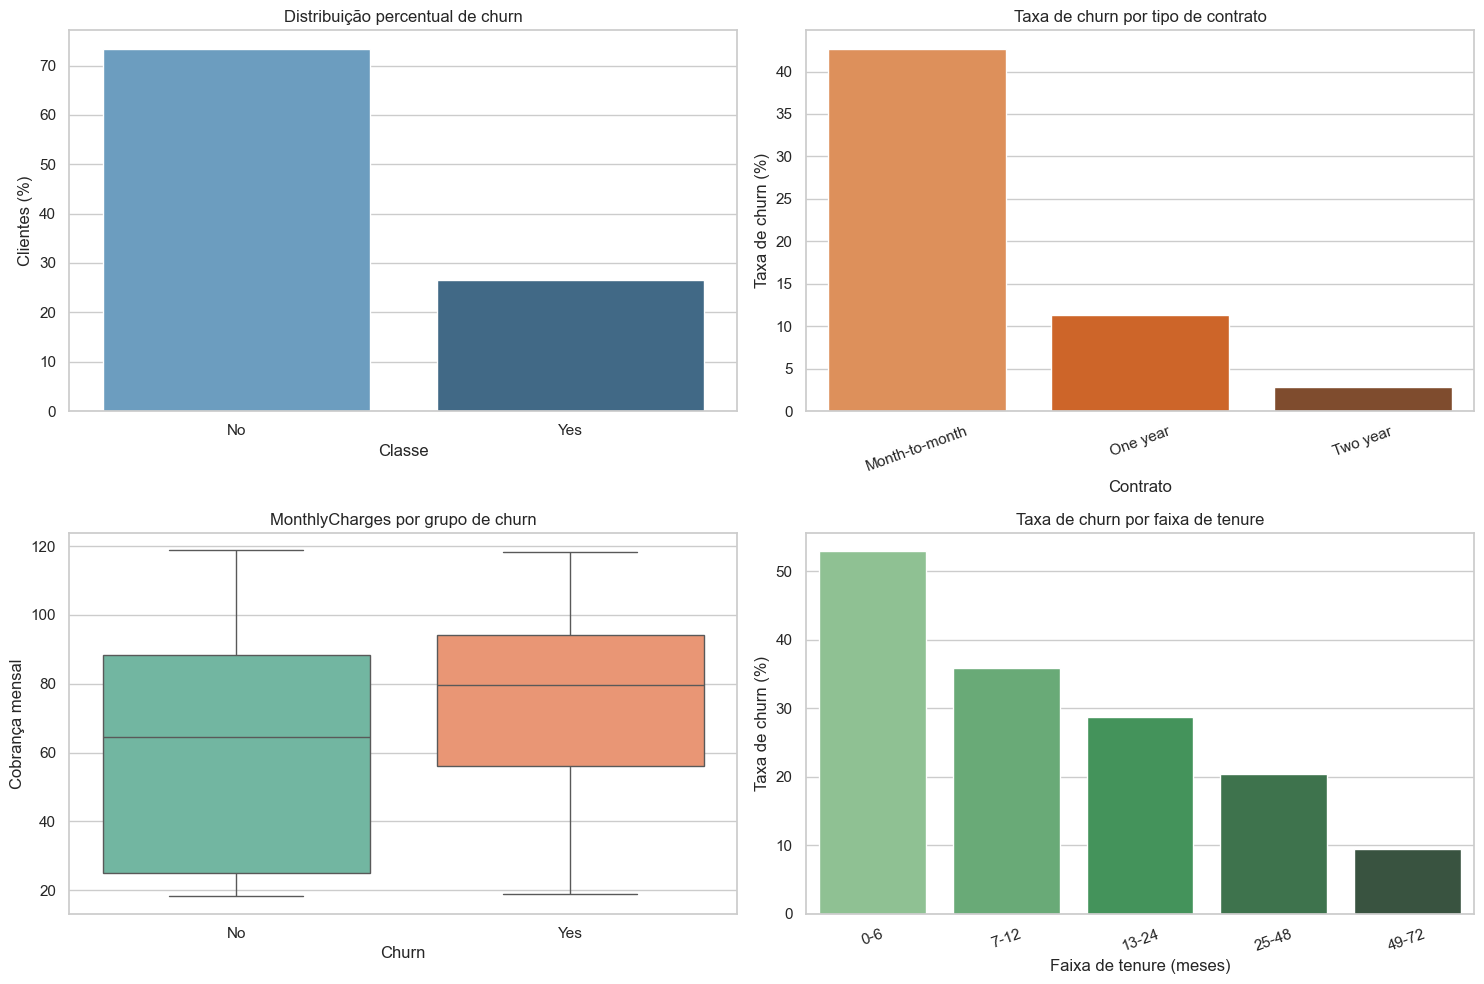

In [36]:
# Código da Questão 4
def run_churn_eda(df: pd.DataFrame, target: str = 'Churn') -> dict:
    analysis = {}
    eda_df = df.copy()

    if target not in eda_df.columns:
        raise ValueError(f"A coluna alvo '{target}' não existe no DataFrame.")

    # 1) Distribuição da classe alvo
    class_distribution = eda_df[target].value_counts(dropna=False).rename_axis('classe').reset_index(name='qtd_clientes')
    class_distribution['pct_clientes'] = (class_distribution['qtd_clientes'] / len(eda_df) * 100).round(2)
    analysis['class_distribution'] = class_distribution

    # 2) Taxas de churn por variáveis categóricas prioritárias
    def build_churn_rate_table(data: pd.DataFrame, column: str, target_col: str) -> pd.DataFrame:
        table = data.groupby(column, dropna=False)[target_col].agg(
            qtd_clientes='count',
            churn_yes=lambda s: (s == 'Yes').sum()
        ).reset_index()
        table['taxa_churn_pct'] = (table['churn_yes'] / table['qtd_clientes'] * 100).round(2)
        return table.sort_values(by='taxa_churn_pct', ascending=False).reset_index(drop=True)

    key_categorical_cols = ['Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling', 'SeniorCitizen']
    for col in key_categorical_cols:
        if col in eda_df.columns:
            analysis[f'churn_by_{col.lower()}'] = build_churn_rate_table(eda_df, col, target)

    # 3) Comparação numérica por grupo-alvo
    key_numeric_cols = [col for col in ['tenure', 'MonthlyCharges', 'TotalCharges'] if col in eda_df.columns]
    numeric_summary = eda_df.groupby(target)[key_numeric_cols].agg(['mean', 'median', 'std']).round(2)
    analysis['numeric_summary_by_target'] = numeric_summary

    # 4) Faixas para leitura de padrão
    if 'tenure' in eda_df.columns:
        eda_df['tenure_band'] = pd.cut(
            eda_df['tenure'],
            bins=[-1, 6, 12, 24, 48, 72],
            labels=['0-6', '7-12', '13-24', '25-48', '49-72']
        )
        analysis['churn_by_tenure_band'] = build_churn_rate_table(eda_df, 'tenure_band', target)

    if 'MonthlyCharges' in eda_df.columns:
        eda_df['monthly_band'] = pd.qcut(eda_df['MonthlyCharges'], q=5, duplicates='drop')
        analysis['churn_by_monthly_band'] = build_churn_rate_table(eda_df, 'monthly_band', target)

    # 5) Correlação simples das variáveis numéricas com churn (target binário)
    target_binary = (eda_df[target] == 'Yes').astype(int)
    numeric_cols_all = eda_df.select_dtypes(include=['number', 'bool']).columns.tolist()
    numeric_cols_all = [col for col in numeric_cols_all if col != target]

    corr_records = []
    for col in numeric_cols_all:
        valid_mask = eda_df[col].notna()
        if valid_mask.sum() == 0:
            continue
        corr_value = np.corrcoef(eda_df.loc[valid_mask, col].astype(float), target_binary.loc[valid_mask])[0, 1]
        corr_records.append({
            'variavel': col,
            'correlacao_com_churn': round(float(corr_value), 4)
        })

    corr_df = pd.DataFrame(corr_records).sort_values(
        by='correlacao_com_churn',
        key=lambda s: s.abs(),
        ascending=False
    ) if corr_records else pd.DataFrame(columns=['variavel', 'correlacao_com_churn'])
    analysis['numeric_correlation_with_churn'] = corr_df

    return analysis


# Usa a base limpa da Questão 3; fallback reproduzível caso a célula anterior não esteja carregada
if 'q3_clean_df' in globals():
    q4_base_df = q3_clean_df.copy()
elif 'clean_telco_data' in globals():
    q4_base_df, _ = clean_telco_data(
        df=df,
        target='Churn',
        totalcharges_strategy='impute_from_monthly_tenure',
        rare_threshold=0.01,
        flag_monetary_suspects=True
    )
else:
    q4_base_df = df.copy()
    for col in q4_base_df.select_dtypes(include=['object']).columns:
        q4_base_df[col] = q4_base_df[col].astype(str).str.strip()
    q4_base_df['TotalCharges'] = pd.to_numeric(q4_base_df['TotalCharges'], errors='coerce')
    missing_mask = q4_base_df['TotalCharges'].isna()
    q4_base_df.loc[missing_mask, 'TotalCharges'] = q4_base_df.loc[missing_mask, 'MonthlyCharges'] * q4_base_df.loc[missing_mask, 'tenure']
    q4_base_df['TotalCharges'] = q4_base_df['TotalCharges'].fillna(q4_base_df['TotalCharges'].median())
    if 'customerID' in q4_base_df.columns:
        q4_base_df = q4_base_df.drop(columns=['customerID'])

q4_results = run_churn_eda(q4_base_df, target='Churn')

# Tabelas principais
print('Distribuição da variável alvo (Churn):')
display(q4_results['class_distribution'])

print('Taxa de churn por tipo de contrato:')
display(q4_results['churn_by_contract'])

print('Taxa de churn por serviço de internet:')
display(q4_results['churn_by_internetservice'])

print('Taxa de churn por método de pagamento:')
display(q4_results['churn_by_paymentmethod'])

print('Resumo numérico por grupo de churn:')
display(q4_results['numeric_summary_by_target'])

print('Taxa de churn por faixa de tempo de contrato (tenure):')
display(q4_results['churn_by_tenure_band'])

print('Correlação das variáveis numéricas com churn (valor absoluto decrescente):')
display(q4_results['numeric_correlation_with_churn'].head(10))

# Resumo textual objetivo para apoiar a conclusão
overall_churn_pct = q4_results['class_distribution'].loc[q4_results['class_distribution']['classe'] == 'Yes', 'pct_clientes'].iloc[0]
top_contract = q4_results['churn_by_contract'].iloc[0]
lowest_contract = q4_results['churn_by_contract'].iloc[-1]
top_internet = q4_results['churn_by_internetservice'].iloc[0]
top_payment = q4_results['churn_by_paymentmethod'].iloc[0]

print('\nResumo analítico objetivo:')
print(f"- Taxa geral de churn: {overall_churn_pct:.2f}%")
print(f"- Maior churn por contrato: {top_contract['Contract']} ({top_contract['taxa_churn_pct']:.2f}%)")
print(f"- Menor churn por contrato: {lowest_contract['Contract']} ({lowest_contract['taxa_churn_pct']:.2f}%)")
print(f"- Maior churn por internet: {top_internet['InternetService']} ({top_internet['taxa_churn_pct']:.2f}%)")
print(f"- Maior churn por pagamento: {top_payment['PaymentMethod']} ({top_payment['taxa_churn_pct']:.2f}%)")

# Visualizações orientadas ao problema
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.barplot(data=q4_results['class_distribution'], x='classe', y='pct_clientes', ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Distribuição percentual de churn')
axes[0, 0].set_xlabel('Classe')
axes[0, 0].set_ylabel('Clientes (%)')

sns.barplot(data=q4_results['churn_by_contract'], x='Contract', y='taxa_churn_pct', ax=axes[0, 1], palette='Oranges_d')
axes[0, 1].set_title('Taxa de churn por tipo de contrato')
axes[0, 1].set_xlabel('Contrato')
axes[0, 1].set_ylabel('Taxa de churn (%)')
axes[0, 1].tick_params(axis='x', rotation=20)

sns.boxplot(data=q4_base_df, x='Churn', y='MonthlyCharges', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('MonthlyCharges por grupo de churn')
axes[1, 0].set_xlabel('Churn')
axes[1, 0].set_ylabel('Cobrança mensal')

sns.barplot(data=q4_results['churn_by_tenure_band'], x='tenure_band', y='taxa_churn_pct', ax=axes[1, 1], palette='Greens_d')
axes[1, 1].set_title('Taxa de churn por faixa de tenure')
axes[1, 1].set_xlabel('Faixa de tenure (meses)')
axes[1, 1].set_ylabel('Taxa de churn (%)')
axes[1, 1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

### Conclusão da Questão 4
A análise exploratória confirmou padrões centrais para o problema de churn na base. A taxa geral de cancelamento foi de **26,54%**, indicando desbalanceamento moderado entre as classes (`No` = 73,46% e `Yes` = 26,54%).

Nos atributos categóricos, o tipo de contrato foi o fator mais discriminante: clientes **Month-to-month** apresentaram a maior taxa de churn (**42,71%**), enquanto contratos longos reduziram fortemente o risco (**One year = 11,27%** e **Two year = 2,83%**). Em serviços de internet, **Fiber optic** concentrou maior churn (**41,89%**), e em pagamento, **Electronic check** teve a maior taxa (**45,29%**).

Nas variáveis numéricas, clientes que cancelaram mostraram, em média, **menor tempo de permanência** (`tenure` médio de 17,98 vs 37,57) e **maior cobrança mensal** (`MonthlyCharges` médio de 74,44 vs 61,27). A análise por faixas reforçou esse padrão: churn de **52,94%** nos primeiros 6 meses, caindo progressivamente até **9,51%** para 49-72 meses.

Assim, a EDA indica um perfil de maior risco associado a início de relacionamento, contrato curto, cobrança mensal mais alta e determinados perfis de serviço/pagamento. Esses achados serão fundamentais para conseguirmos orientar a modelagem preditiva e estratégias de retenção nas próximas etapas.

## Questão 5 – Associação entre variáveis

**Enunciado:**  
Faça um código em Python para medir a associação entre as variáveis explicativas e a variável principal da análise. Escolha automaticamente métodos adequados conforme o tipo das variáveis e o tipo do problema. Ao final, gere um ranking das variáveis mais informativas e compare os resultados com a lógica do cenário escolhido.

### Raciocínio
Como o problema central foi definido como **classificação binária** (`Churn` = Yes/No), a análise de associação será automática por tipo de variável:
- Para variáveis numéricas vs alvo binário: **correlação ponto-bisserial**.
- Para variáveis categóricas vs alvo binário: **V de Cramér** (a partir do teste qui-quadrado).

A estratégia retorna uma tabela única com método aplicado, estatística de associação, p-valor e ranking final por magnitude de associação. Em seguida, os resultados serão comparados com os padrões observados na Questão 4 (contrato, tenure, tipo de internet e forma de pagamento).

### Desenvolvimento
Implementar uma função reutilizável `run_association_analysis`, aplicar na base limpa e gerar ranking das variáveis mais informativas com visualização.

Tipo de problema detectado automaticamente:
- classificacao_binaria

Regras de método por tipo de variável:


,tipo_variavel,metodo,descricao
0,numerica,point_biserial,Correlação entre variável numérica e alvo binário
1,categorica,cramers_v,Associação categórica com alvo binário via qui...


Top 15 variáveis mais informativas:


,variavel,tipo_variavel,metodo,estatistica,score_associacao,pvalue,direcao_numerica,ranking
0,Contract,categorica,cramers_v,0.4101,0.4101,0.0,nao_aplicavel,1
1,tenure,numerica,point_biserial,-0.3522,0.3522,0.0,negativa,2
2,InternetService,categorica,cramers_v,0.3225,0.3225,0.0,nao_aplicavel,3
3,PaymentMethod,categorica,cramers_v,0.3034,0.3034,0.0,nao_aplicavel,4
4,TotalCharges,numerica,point_biserial,-0.1983,0.1983,0.0,negativa,5
5,MonthlyCharges,numerica,point_biserial,0.1934,0.1934,0.0,positiva,6
6,PaperlessBilling,categorica,cramers_v,0.1915,0.1915,0.0,nao_aplicavel,7
7,OnlineSecurity,categorica,cramers_v,0.1709,0.1709,0.0,nao_aplicavel,8
8,TechSupport,categorica,cramers_v,0.1643,0.1643,0.0,nao_aplicavel,9
9,Dependents,categorica,cramers_v,0.1639,0.1639,0.0,nao_aplicavel,10


Top 5 numéricas:


,variavel,tipo_variavel,metodo,estatistica,score_associacao,pvalue,direcao_numerica,ranking
1,tenure,numerica,point_biserial,-0.3522,0.3522,0.000000,negativa,2
4,TotalCharges,numerica,point_biserial,-0.1983,0.1983,0.000000,negativa,5
5,MonthlyCharges,numerica,point_biserial,0.1934,0.1934,0.000000,positiva,6
10,SeniorCitizen,numerica,point_biserial,0.1509,0.1509,0.000000,positiva,11
16,monetary_suspect_flag,numerica,point_biserial,-0.0404,0.0404,0.000692,negativa,17


Top 5 categóricas:


,variavel,tipo_variavel,metodo,estatistica,score_associacao,pvalue,direcao_numerica,ranking
0,Contract,categorica,cramers_v,0.4101,0.4101,0.0,nao_aplicavel,1
2,InternetService,categorica,cramers_v,0.3225,0.3225,0.0,nao_aplicavel,3
3,PaymentMethod,categorica,cramers_v,0.3034,0.3034,0.0,nao_aplicavel,4
6,PaperlessBilling,categorica,cramers_v,0.1915,0.1915,0.0,nao_aplicavel,7
7,OnlineSecurity,categorica,cramers_v,0.1709,0.1709,0.0,nao_aplicavel,8


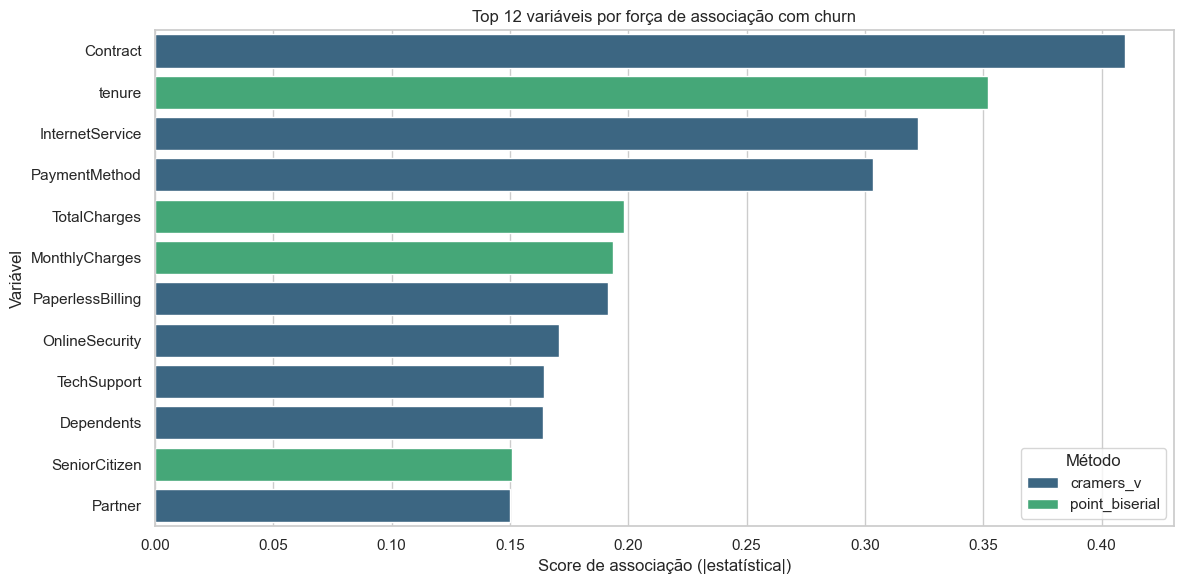

In [37]:
# Código da Questão 5
from scipy.stats import chi2_contingency, pointbiserialr

def detect_problem_type(target_series: pd.Series) -> str:
    unique_values = target_series.dropna().nunique()
    if unique_values == 2:
        return 'classificacao_binaria'
    if unique_values <= 10:
        return 'classificacao_multiclasse'
    return 'regressao'


def cramers_v_from_crosstab(crosstab: pd.DataFrame) -> float:
    if crosstab.shape[0] < 2 or crosstab.shape[1] < 2:
        return 0.0

    chi2, _, _, _ = chi2_contingency(crosstab)
    n = crosstab.to_numpy().sum()
    if n == 0:
        return 0.0

    r, k = crosstab.shape
    denominator = min(r - 1, k - 1)
    if denominator <= 0:
        return 0.0

    return float(np.sqrt((chi2 / n) / denominator))


def run_association_analysis(df: pd.DataFrame, target: str = 'Churn') -> dict:
    analysis_df = df.copy()
    if target not in analysis_df.columns:
        raise ValueError(f"A coluna alvo '{target}' não está no DataFrame.")

    problem_type = detect_problem_type(analysis_df[target])
    if problem_type != 'classificacao_binaria':
        raise ValueError('Esta implementação foi desenhada para classificação binária.')

    y_raw = analysis_df[target].astype(str).str.strip()
    # Padroniza alvo binário para 0/1 sem assumir apenas Yes/No
    if set(y_raw.unique()) == {'No', 'Yes'}:
        y_binary = y_raw.map({'No': 0, 'Yes': 1})
    else:
        factorized, uniques = pd.factorize(y_raw)
        if len(uniques) != 2:
            raise ValueError('Alvo não é binário após padronização.')
        y_binary = pd.Series(factorized, index=y_raw.index)

    feature_cols = [col for col in analysis_df.columns if col != target]
    records = []

    for col in feature_cols:
        series = analysis_df[col]
        valid_rows = series.notna() & y_binary.notna()

        if valid_rows.sum() == 0:
            continue

        if pd.api.types.is_numeric_dtype(series) or pd.api.types.is_bool_dtype(series):
            method = 'point_biserial'
            x = pd.to_numeric(series, errors='coerce')
            valid_rows = x.notna() & y_binary.notna()

            if valid_rows.sum() < 3 or x[valid_rows].nunique() < 2:
                statistic = 0.0
                pvalue = np.nan
            else:
                corr, pvalue = pointbiserialr(y_binary[valid_rows], x[valid_rows])
                statistic = float(0.0 if pd.isna(corr) else corr)

            score = abs(statistic)
            direction = 'positiva' if statistic > 0 else 'negativa' if statistic < 0 else 'nula'

        else:
            method = 'cramers_v'
            x = series.astype(str).str.strip()
            contingency = pd.crosstab(x, y_binary)

            if contingency.shape[0] < 2 or contingency.shape[1] < 2:
                statistic = 0.0
                pvalue = np.nan
            else:
                statistic = cramers_v_from_crosstab(contingency)
                _, pvalue, _, _ = chi2_contingency(contingency)

            score = abs(statistic)
            direction = 'nao_aplicavel'

        records.append({
            'variavel': col,
            'tipo_variavel': 'numerica' if method == 'point_biserial' else 'categorica',
            'metodo': method,
            'estatistica': round(float(statistic), 4),
            'score_associacao': round(float(score), 4),
            'pvalue': round(float(pvalue), 6) if pd.notna(pvalue) else np.nan,
            'direcao_numerica': direction
        })

    ranking_df = pd.DataFrame(records).sort_values(
        by='score_associacao', ascending=False
    ).reset_index(drop=True)
    ranking_df['ranking'] = ranking_df.index + 1

    top_numeric_df = ranking_df[ranking_df['tipo_variavel'] == 'numerica'].head(5)
    top_categorical_df = ranking_df[ranking_df['tipo_variavel'] == 'categorica'].head(5)

    return {
        'problem_type': problem_type,
        'method_rules': pd.DataFrame([
            {'tipo_variavel': 'numerica', 'metodo': 'point_biserial', 'descricao': 'Correlação entre variável numérica e alvo binário'},
            {'tipo_variavel': 'categorica', 'metodo': 'cramers_v', 'descricao': 'Associação categórica com alvo binário via qui-quadrado'}
        ]),
        'association_ranking': ranking_df,
        'top_numeric': top_numeric_df,
        'top_categorical': top_categorical_df
    }


# Base de análise: prioriza base limpa da Questão 3
if 'q3_clean_df' in globals():
    q5_base_df = q3_clean_df.copy()
else:
    q5_base_df = df.copy()
    for col in q5_base_df.select_dtypes(include=['object']).columns:
        q5_base_df[col] = q5_base_df[col].astype(str).str.strip()
    q5_base_df['TotalCharges'] = pd.to_numeric(q5_base_df['TotalCharges'], errors='coerce')
    missing_mask = q5_base_df['TotalCharges'].isna()
    q5_base_df.loc[missing_mask, 'TotalCharges'] = q5_base_df.loc[missing_mask, 'MonthlyCharges'] * q5_base_df.loc[missing_mask, 'tenure']
    q5_base_df['TotalCharges'] = q5_base_df['TotalCharges'].fillna(q5_base_df['TotalCharges'].median())
    if 'customerID' in q5_base_df.columns:
        q5_base_df = q5_base_df.drop(columns=['customerID'])

q5_results = run_association_analysis(q5_base_df, target='Churn')

print('Tipo de problema detectado automaticamente:')
print(f"- {q5_results['problem_type']}")

print('\nRegras de método por tipo de variável:')
display(q5_results['method_rules'])

print('Top 15 variáveis mais informativas:')
display(q5_results['association_ranking'].head(15))

print('Top 5 numéricas:')
display(q5_results['top_numeric'])

print('Top 5 categóricas:')
display(q5_results['top_categorical'])

# Visualização do ranking de associação
top_plot_df = q5_results['association_ranking'].head(12).copy()
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_plot_df,
    x='score_associacao',
    y='variavel',
    hue='metodo',
    dodge=False,
    palette='viridis'
)
plt.title('Top 12 variáveis por força de associação com churn')
plt.xlabel('Score de associação (|estatística|)')
plt.ylabel('Variável')
plt.legend(title='Método')
plt.tight_layout()
plt.show()

### Conclusão da Questão 5
A seleção automática de métodos funcionou conforme o tipo de variável no cenário de **classificação binária**: `point_biserial` para variáveis numéricas e `cramers_v` para categóricas. O ranking final mostrou que os atributos mais informativos para churn foram, em ordem, **Contract (0.4101)**, **tenure (0.3522)**, **InternetService (0.3225)** e **PaymentMethod (0.3034)**, seguidos por **TotalCharges (0.1983)** e **MonthlyCharges (0.1934)**.

Entre as numéricas, `tenure` teve associação negativa mais forte com churn (maior permanência, menor chance de cancelamento), enquanto `MonthlyCharges` apresentou associação positiva (cobrança mensal mais alta, maior risco de churn). Entre as categóricas, `Contract`, `InternetService` e `PaymentMethod` concentraram os maiores sinais de associação.

Os resultados são consistentes com a lógica observada na questão anterior: maior churn em contratos mensais, em clientes de fibra óptica e em pagamento via cheque eletrônico, além de maior risco nos clientes com menor tempo de casa. Assim, o ranking obtido reforça que os principais drivers detectados na análise exploratória também aparecem como as variáveis mais informativas para modelagem.

## Questão 6 – Engenharia de atributos

**Enunciado:**  
Faça um código em Python para criar pelo menos cinco novos atributos a partir da base original. Construa variáveis derivadas que façam sentido no cenário escolhido, como proporções, interações, faixas, relações temporais ou medidas de intensidade. Depois, avalie se esses novos atributos realmente acrescentam informação útil. Organize essa etapa em uma função reutilizável.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [28]:
# Código da Questão 6

### Conclusão da Questão 6
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 7 – Pré-processamento

**Enunciado:**  
Faça um código em Python para montar um pipeline completo de pré-processamento com `Pipeline` e `ColumnTransformer`. Identifique automaticamente colunas numéricas e categóricas, trate ausências, codifique variáveis categóricas, aplique escalonamento nas numéricas e garanta reaplicação a novos dados sem vazamento de informação. Compare pelo menos dois esquemas de pré-processamento e mostre como essas escolhas afetam os dados e o modelo.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [29]:
# Código da Questão 7

### Conclusão da Questão 7
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 8 – Modelagem com KNN

**Enunciado:**  
Faça um código em Python para dividir a base em treino, validação e teste de forma adequada ao problema escolhido. Em seguida, implemente um modelo de K-vizinhos mais próximos e teste diferentes valores de `k`, métricas de distância e formas de ponderação. Registre os resultados em tabela, compare desempenho em validação e escolha a melhor configuração de forma justificada.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [30]:
# Código da Questão 8

### Conclusão da Questão 8
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 9 – Comparação de modelos

**Enunciado:**  
Faça um código em Python para avaliar o KNN em diferentes cenários de preparação dos dados, como uso ou não de padronização, presença ou ausência de atributos derivados, uso de todas as variáveis ou de um subconjunto selecionado, e tratamento do desbalanceamento quando fizer sentido. Depois, implemente um segundo modelo supervisionado e compare com o melhor KNN em métricas, tempo de execução e perfil dos erros. Conclua se o KNN é ou não uma boa escolha para a base utilizada.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [31]:
# Código da Questão 9

### Conclusão da Questão 9
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Questão 10 – Consolidação da solução

**Enunciado:**  
Faça um código em Python para consolidar toda a solução em um fluxo reutilizável. Implemente uma função que receba um novo caso em formato de dicionário ou `DataFrame` de uma linha, aplique o pipeline construído e retorne a previsão final de forma interpretável. Depois, gere um relatório resumido com a base escolhida, os principais problemas encontrados, os atributos mais relevantes, a melhor configuração do modelo, as métricas finais e uma recomendação executiva. Finalize com uma avaliação crítica sobre a maturidade da solução para uso prático.

### Raciocínio
Escreva aqui a estratégia adotada para responder à questão, explicando de forma objetiva a lógica da análise.

### Desenvolvimento
Implemente abaixo o código da questão.

In [32]:
# Código da Questão 10

### Conclusão da Questão 10
Registre aqui as principais interpretações e conclusões obtidas com base nos resultados.

## Conclusão Final

Apresente uma síntese geral do trabalho, destacando:

- principais problemas encontrados na base;
- principais decisões metodológicas;
- melhor configuração de modelo obtida;
- limitações da análise;
- avaliação final da adequação da solução ao cenário escolhido.

**Bom trabalho!**